## Import Libraries


In [49]:
import numpy as np
import pandas as pd
import glob
import os
import gc  
import joblib

import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from fastai.tabular.all import df_shrink
from fastcore.parallel import *

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

## Loading Dataset

In [50]:
folder_path = 'data/archive'
files = glob.glob(os.path.join(folder_path, "*.parquet"))

print(f"Found {len(files)} CSV files. Loading directly into memory...\n")

individual_dfs = []
for file in files:
    df = pd.read_parquet(file, engine='pyarrow') 
    individual_dfs.append(df)
    
    print(f"  - Loaded: {os.path.basename(file)} | Shape: {df.shape}")

print(f"\n✅ Success! You now have {len(individual_dfs)} DataFrames loaded in your 'individual_dfs' list.")

Found 17 CSV files. Loading directly into memory...

  - Loaded: DNS-testing.parquet | Shape: (6703, 78)
  - Loaded: LDAP-testing.parquet | Shape: (2831, 78)
  - Loaded: LDAP-training.parquet | Shape: (6715, 78)
  - Loaded: MSSQL-testing.parquet | Shape: (8083, 78)
  - Loaded: MSSQL-training.parquet | Shape: (10974, 78)
  - Loaded: NetBIOS-testing.parquet | Shape: (2225, 78)
  - Loaded: NetBIOS-training.parquet | Shape: (1631, 78)
  - Loaded: NTP-testing.parquet | Shape: (134674, 78)
  - Loaded: Portmap-training.parquet | Shape: (5105, 78)
  - Loaded: SNMP-testing.parquet | Shape: (4018, 78)
  - Loaded: Syn-testing.parquet | Shape: (907, 78)
  - Loaded: Syn-training.parquet | Shape: (70336, 78)
  - Loaded: TFTP-testing.parquet | Shape: (121833, 78)
  - Loaded: UDP-testing.parquet | Shape: (12462, 78)
  - Loaded: UDP-training.parquet | Shape: (17770, 78)
  - Loaded: UDPLag-testing.parquet | Shape: (12465, 78)
  - Loaded: UDPLag-training.parquet | Shape: (12639, 78)

✅ Success! You now h

#### Column name consistency

In [51]:
col_name_consistency = {
'Flow ID': 'Flow ID',
'Source IP': 'Source IP',
'Src IP':  'Source IP',
'Source Port': 'Source Port',
'Src Port': 'Source Port',
'Destination IP': 'Destination IP',
'Dst IP': 'Destination IP',
'Destination Port': 'Destination Port',
'Dst Port': 'Destination Port',
'Protocol': 'Protocol',
'Timestamp': 'Timestamp',
'Flow Duration': 'Flow Duration',
'Total Fwd Packets': 'Total Fwd Packets',
'Tot Fwd Pkts': 'Total Fwd Packets',
'Total Backward Packets': 'Total Backward Packets',
'Tot Bwd Pkts': 'Total Backward Packets',
'Total Length of Fwd Packets': 'Fwd Packets Length Total',
'TotLen Fwd Pkts': 'Fwd Packets Length Total',
'Total Length of Bwd Packets': 'Bwd Packets Length Total',
'TotLen Bwd Pkts': 'Bwd Packets Length Total',
'Fwd Packet Length Max': 'Fwd Packet Length Max',
'Fwd Pkt Len Max': 'Fwd Packet Length Max',
'Fwd Packet Length Min': 'Fwd Packet Length Min',
'Fwd Pkt Len Min': 'Fwd Packet Length Min',
'Fwd Packet Length Mean': 'Fwd Packet Length Mean',
'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
'Fwd Packet Length Std': 'Fwd Packet Length Std',
'Fwd Pkt Len Std': 'Fwd Packet Length Std',
'Bwd Packet Length Max': 'Bwd Packet Length Max',
'Bwd Pkt Len Max': 'Bwd Packet Length Max',
'Bwd Packet Length Min': 'Bwd Packet Length Min',
'Bwd Pkt Len Min': 'Bwd Packet Length Min',
'Bwd Packet Length Mean': 'Bwd Packet Length Mean',
'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
'Bwd Packet Length Std': 'Bwd Packet Length Std',
'Bwd Pkt Len Std': 'Bwd Packet Length Std',
'Flow Bytes/s': 'Flow Bytes/s',
'Flow Byts/s': 'Flow Bytes/s',
'Flow Packets/s': 'Flow Packets/s',
'Flow Pkts/s': 'Flow Packets/s',
'Flow IAT Mean': 'Flow IAT Mean',
'Flow IAT Std': 'Flow IAT Std',
'Flow IAT Max': 'Flow IAT Max',
'Flow IAT Min': 'Flow IAT Min',
'Fwd IAT Total': 'Fwd IAT Total',
'Fwd IAT Tot': 'Fwd IAT Total',
'Fwd IAT Mean': 'Fwd IAT Mean',
'Fwd IAT Std': 'Fwd IAT Std',
'Fwd IAT Max': 'Fwd IAT Max',
'Fwd IAT Min': 'Fwd IAT Min',
'Bwd IAT Total': 'Bwd IAT Total',
'Bwd IAT Tot': 'Bwd IAT Total',
'Bwd IAT Mean': 'Bwd IAT Mean',
'Bwd IAT Std': 'Bwd IAT Std',
'Bwd IAT Max': 'Bwd IAT Max',
'Bwd IAT Min': 'Bwd IAT Min',
'Fwd PSH Flags': 'Fwd PSH Flags',
'Bwd PSH Flags': 'Bwd PSH Flags',
'Fwd URG Flags': 'Fwd URG Flags',
'Bwd URG Flags': 'Bwd URG Flags',
'Fwd Header Length': 'Fwd Header Length',
'Fwd Header Len': 'Fwd Header Length',
'Bwd Header Length': 'Bwd Header Length',
'Bwd Header Len': 'Bwd Header Length',
'Fwd Packets/s': 'Fwd Packets/s',
'Fwd Pkts/s': 'Fwd Packets/s',
'Bwd Packets/s': 'Bwd Packets/s',
'Bwd Pkts/s': 'Bwd Packets/s',
'Min Packet Length': 'Packet Length Min',
'Pkt Len Min': 'Packet Length Min',
'Max Packet Length': 'Packet Length Max',
'Pkt Len Max': 'Packet Length Max',
'Packet Length Mean': 'Packet Length Mean',
'Pkt Len Mean': 'Packet Length Mean',
'Packet Length Std': 'Packet Length Std',
'Pkt Len Std': 'Packet Length Std',
'Packet Length Variance': 'Packet Length Variance',
'Pkt Len Var': 'Packet Length Variance',
'FIN Flag Count': 'FIN Flag Count',
'FIN Flag Cnt': 'FIN Flag Count',
'SYN Flag Count': 'SYN Flag Count',
'SYN Flag Cnt': 'SYN Flag Count',
'RST Flag Count': 'RST Flag Count',
'RST Flag Cnt': 'RST Flag Count',
'PSH Flag Count': 'PSH Flag Count',
'PSH Flag Cnt': 'PSH Flag Count',
'ACK Flag Count': 'ACK Flag Count',
'ACK Flag Cnt': 'ACK Flag Count',
'URG Flag Count': 'URG Flag Count',
'URG Flag Cnt': 'URG Flag Count',
'CWE Flag Count': 'CWE Flag Count',
'CWE Flag Cnt': 'CWE Flag Count',
'ECE Flag Count': 'ECE Flag Count',
'ECE Flag Cnt': 'ECE Flag Count',
'Down/Up Ratio': 'Down/Up Ratio',
'Average Packet Size': 'Avg Packet Size',
'Pkt Size Avg': 'Avg Packet Size',
'Avg Fwd Segment Size': 'Avg Fwd Segment Size',
'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
'Avg Bwd Segment Size': 'Avg Bwd Segment Size',
'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
'Fwd Avg Bytes/Bulk': 'Fwd Avg Bytes/Bulk',
'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk': 'Fwd Avg Packets/Bulk',
'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate': 'Fwd Avg Bulk Rate',
'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk': 'Bwd Avg Bytes/Bulk',
'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk': 'Bwd Avg Packets/Bulk',
'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate': 'Bwd Avg Bulk Rate',
'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
'Subflow Fwd Packets': 'Subflow Fwd Packets',
'Subflow Fwd Pkts': 'Subflow Fwd Packets',
'Subflow Fwd Bytes': 'Subflow Fwd Bytes',
'Subflow Fwd Byts': 'Subflow Fwd Bytes',
'Subflow Bwd Packets': 'Subflow Bwd Packets',
'Subflow Bwd Pkts': 'Subflow Bwd Packets',
'Subflow Bwd Bytes': 'Subflow Bwd Bytes',
'Subflow Bwd Byts': 'Subflow Bwd Bytes',
'Init_Win_bytes_forward': 'Init Fwd Win Bytes',
'Init Fwd Win Byts': 'Init Fwd Win Bytes',
'Init_Win_bytes_backward': 'Init Bwd Win Bytes',
'Init Bwd Win Byts': 'Init Bwd Win Bytes',
'act_data_pkt_fwd': 'Fwd Act Data Packets',
'Fwd Act Data Pkts': 'Fwd Act Data Packets',
'min_seg_size_forward': 'Fwd Seg Size Min',
'Fwd Seg Size Min': 'Fwd Seg Size Min',
'Active Mean': 'Active Mean',
'Active Std': 'Active Std',
'Active Max': 'Active Max',
'Active Min': 'Active Min',
'Idle Mean': 'Idle Mean',
'Idle Std': 'Idle Std',
'Idle Max': 'Idle Max',
'Idle Min': 'Idle Min',
'Label': 'Label'
}

#### Implementation of column name consistency 

In [52]:
for df in individual_dfs:
    df.columns = df.columns.str.strip()   
    df.rename(columns=col_name_consistency, inplace=True)
[i.shape for i in individual_dfs]

[(6703, 78),
 (2831, 78),
 (6715, 78),
 (8083, 78),
 (10974, 78),
 (2225, 78),
 (1631, 78),
 (134674, 78),
 (5105, 78),
 (4018, 78),
 (907, 78),
 (70336, 78),
 (121833, 78),
 (12462, 78),
 (17770, 78),
 (12465, 78),
 (12639, 78)]

## Feature Selection

In [53]:
drop_columns = [ 
    "Flow ID",    
    'Fwd Header Length.1',
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Timestamp",
    "Unnamed: 0",        
    "SimillarHTTP",           # Metadata
    "Inbound",                # Inconsistently captured/ doesnt provide any info about traffic
    "Fwd Avg Bytes/Bulk",     
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",      # 0 value columns
    "Fwd URG Flags",    
    "Bwd PSH Flags",    
    "Bwd URG Flags",    
    "FIN Flag Count",   
    "PSH Flag Count",   
    "ECE Flag Count"          # 0 variance flags 
]

In [54]:
for df in individual_dfs:
    df.drop(columns=drop_columns, inplace=True, errors='ignore') 

In [55]:
individual_dfs[0].dtypes


Protocol                        int8
Flow Duration                  int32
Total Fwd Packets              int16
Total Backward Packets         int16
Fwd Packets Length Total     float32
                              ...   
Idle Mean                    float32
Idle Std                     float32
Idle Max                     float32
Idle Min                     float32
Label                       category
Length: 66, dtype: object

## Downcasting Large Csvs 

In [56]:
# Process one by one to save RAM
individual_dfs = [df_shrink(df) for df in individual_dfs]
individual_dfs = parallel(f=df_shrink, items=individual_dfs, n_workers=2, progress=True)

# Reduces memory usage around 50%, by converting columns with only small numbers to float64 or int 64 to a float16 or int8 

## Combining Csvs into one df

In [57]:
df = pd.concat(individual_dfs, ignore_index=True)

print(f"Successfully merged {len(individual_dfs)} DataFrames!")
print(f"Master DataFrame Shape: {df.shape}")

# Deleting the list frees up a massive amount of RAM.

del individual_dfs
gc.collect() 
print("Cleared individual pieces from RAM.")

Successfully merged 17 DataFrames!
Master DataFrame Shape: (431371, 66)
Cleared individual pieces from RAM.


In [58]:
df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431366,6,53,1,2,0.0,0.0,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
431367,6,66,1,2,0.0,0.0,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
431368,17,26288,2,2,96.0,96.0,48.0,48.0,48.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
431369,6,30679,1,1,0.0,0.0,0.0,0.0,0.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [59]:
df["Label"].unique()

<ArrowStringArray>
[    'DrDoS_DNS',        'Benign',    'DrDoS_LDAP',       'NetBIOS',
          'LDAP',   'DrDoS_MSSQL',         'MSSQL', 'DrDoS_NetBIOS',
     'DrDoS_NTP',       'Portmap',    'DrDoS_SNMP',           'Syn',
          'TFTP',     'DrDoS_UDP',           'UDP',       'UDP-lag',
       'WebDDoS',        'UDPLag']
Length: 18, dtype: str

In [60]:
# Same Labels with different names

# Dictionary that maps the "bad" names to the "standard" names
label_replacements = {
    'DrDoS_DNS': 'DNS',
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_NetBIOS': 'NetBIOS',
    'DrDoS_NTP':'NTP',
    'DrDoS_SNMP':'SNMP',
    'DrDoS_UDP': 'UDP',
    'UDPLag': 'UDP-lag' 
}

# Apply the replacement to label column 
df['Label'] = df['Label'].replace(label_replacements)

print("Cleaned Label Value Counts:")
print(df['Label'].value_counts())

Cleaned Label Value Counts:
Label
NTP        121368
TFTP        98917
Benign      97831
Syn         49373
UDP         28510
MSSQL       14735
UDP-lag      8927
DNS          3669
LDAP         3346
SNMP         2717
NetBIOS      1242
Portmap       685
WebDDoS        51
Name: count, dtype: int64


## Data Cleaning (Handling Missing values, nulls and Infs)

In [61]:
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

In [62]:
df[['Flow Packets/s', 'Flow Bytes/s']]

,Flow Packets/s,Flow Bytes/s
0,4.166667e+04,6.133333e+07
1,1.000000e+06,1.472000e+09
2,2.000000e+06,2.944000e+09
3,2.000000e+06,2.944000e+09
4,2.000000e+06,2.896000e+09
...,...,...
431366,5.660377e+04,0.000000e+00
431367,4.545455e+04,0.000000e+00
431368,1.521607e+02,7.303713e+03
431369,6.519117e+01,0.000000e+00


In [63]:
df.groupby("Label")["Flow Packets/s"].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Benign,97831.0,1.040900e+05,395473.093750,0.033920,45.065979,1.897983e+02,3.348523e+02,3000000.0
DNS,3669.0,1.054283e+06,851393.437500,2.996330,43478.261719,1.000000e+06,2.000000e+06,2000000.0
LDAP,3346.0,1.203087e+06,834658.375000,0.709807,82057.826172,1.000000e+06,2.000000e+06,2000000.0
MSSQL,14735.0,1.313646e+06,830764.625000,0.340277,400000.000000,2.000000e+06,2.000000e+06,2000000.0
NTP,121368.0,7.936310e+04,144791.906250,0.196703,10207.336670,3.829837e+04,1.156078e+05,4000000.0
NetBIOS,1242.0,7.781711e+05,869775.187500,0.080083,41666.667969,5.144748e+04,2.000000e+06,2000000.0
Portmap,685.0,3.872413e+05,659100.500000,0.042459,30303.031250,4.255319e+04,4.000000e+05,2000000.0
SNMP,2717.0,1.300432e+06,678142.687500,4.062073,1000000.000000,1.000000e+06,2.000000e+06,2000000.0
Syn,49373.0,9.328572e+03,58098.078125,0.039063,0.225467,3.002486e-01,5.275210e-01,2000000.0


In [64]:
# Identify critical Inf-heavy columns 

CRITICAL_INF_COLS = ["Flow Bytes/s", "Flow Packets/s"]
critical_found = [col for col in CRITICAL_INF_COLS]

for col in critical_found:
    inf_count_col = np.isinf(df[col]).sum()
    if inf_count_col > 0:
        # Median of FINITE values only (ignoring Inf and NaN)
        finite_median = df.loc[np.isfinite(df[col]), col].median()
        df[col] = df[col].replace([np.inf, -np.inf], finite_median)
        print(f"[PRESERVE] '{col}': {inf_count_col:,} Inf → median ({finite_median:,.2f})")
df[col] = np.log1p(df[col])
print(f"[TRANSFORM] '{col}': Applied np.log1p to compress scale.")

[TRANSFORM] 'Flow Packets/s': Applied np.log1p to compress scale.


In [65]:
df[['Flow Packets/s', 'Flow Bytes/s']]

,Flow Packets/s,Flow Bytes/s
0,10.637481,6.133333e+07
1,13.815512,1.472000e+09
2,14.508658,2.944000e+09
3,14.508658,2.944000e+09
4,14.508658,2.896000e+09
...,...,...
431366,10.943849,0.000000e+00
431367,10.724490,0.000000e+00
431368,5.031487,7.303713e+03
431369,4.192547,0.000000e+00


In [66]:
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

In [67]:
df.isna().sum().sum()

np.int64(0)

In [68]:
df.dropna(inplace=True)

In [69]:
df.duplicated().sum()

np.int64(9412)

In [70]:
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True, drop=True)

In [71]:
df.shape

(421959, 66)

In [72]:

print("CLASS DISTRIBUTION (Label)")
print("=" * 60)
print(df['Label'].value_counts())


CLASS DISTRIBUTION (Label)
Label
NTP        121368
TFTP        98914
Benign      94568
Syn         47779
UDP         27525
MSSQL       12228
UDP-lag      8915
DNS          3669
LDAP         2722
SNMP         2702
NetBIOS       833
Portmap       685
WebDDoS        51
Name: count, dtype: int64


## X and y split

In [73]:
y = df["Label"].copy()
X = df.drop(columns=["Label"])

print(f"Target (y) : {y.shape[0]:,} samples, {y.nunique()} classes")
print(f"Features(X): {X.shape[0]:,} rows × {X.shape[1]} columns\n")

Target (y) : 421,959 samples, 13 classes
Features(X): 421,959 rows × 65 columns



In [74]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 421959 entries, 0 to 421958
Data columns (total 65 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  421959 non-null  int8   
 1   Flow Duration             421959 non-null  int32  
 2   Total Fwd Packets         421959 non-null  int32  
 3   Total Backward Packets    421959 non-null  int16  
 4   Fwd Packets Length Total  421959 non-null  float32
 5   Bwd Packets Length Total  421959 non-null  float32
 6   Fwd Packet Length Max     421959 non-null  float32
 7   Fwd Packet Length Min     421959 non-null  float32
 8   Fwd Packet Length Mean    421959 non-null  float32
 9   Fwd Packet Length Std     421959 non-null  float32
 10  Bwd Packet Length Max     421959 non-null  float32
 11  Bwd Packet Length Min     421959 non-null  float32
 12  Bwd Packet Length Mean    421959 non-null  float32
 13  Bwd Packet Length Std     421959 non-null  float32
 14 

In [75]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Filter out the redundant features

print("Removing highly correlated features...")
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features that are more than 95% identical to another feature
threshold = 0.95
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
X_clean = X.drop(columns=to_drop)

print(f"Dropped {len(to_drop)} redundant features.")
print(f"Features remaining in the pool: {X_clean.shape[1]}")

# Select the absolute Top 15 features

print("\nRanking the top 15 features from the clean pool...")

# We use Random Forest here just as a tool to rank importance
feature_ranker = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
feature_ranker.fit(X_clean, y)

# Extract the rankings
feat_importances = pd.Series(feature_ranker.feature_importances_, index=X_clean.columns)

# Isolate the names of the top 15 features
top_15_feature_names = feat_importances.nlargest(15).index.tolist()

# Create your final ML training dataset

X_final_15 = X_clean[top_15_feature_names]

print("\n✅ Success! Your ML-ready dataset is prepared.")
print(f"Shape of X_final_15: {X_final_15.shape} (Rows, Columns)\n")

print("The 15 features we will use to train models:")
for i, feature in enumerate(top_15_feature_names, 1):
    print(f"{i}. {feature}")

Removing highly correlated features...
Dropped 21 redundant features.
Features remaining in the pool: 44

Ranking the top 15 features from the clean pool...

✅ Success! Your ML-ready dataset is prepared.
Shape of X_final_15: (421959, 15) (Rows, Columns)

The 15 features we will use to train models:
1. Fwd Packet Length Min
2. Fwd Packet Length Max
3. Packet Length Max
4. Fwd Packets Length Total
5. Flow Bytes/s
6. Bwd Packets/s
7. Fwd Packets/s
8. Flow Packets/s
9. Fwd Act Data Packets
10. Flow IAT Std
11. Flow IAT Max
12. Flow IAT Mean
13. Flow Duration
14. Total Backward Packets
15. ACK Flag Count


In [76]:
X = X_final_15

## Train and Test Split

In [77]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

# --- Report ---
print("=" * 60)
print("TRAIN / TEST SPLIT SUMMARY")
print("=" * 60)
print(f"  Test size          : {TEST_SIZE * 100:.0f}%")
print(f"  Random state       : {RANDOM_STATE}")
print(f"\n  X_train            : {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"  X_test             : {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"  y_train            : {y_train.shape[0]:,} samples")
print(f"  y_test             : {y_test.shape[0]:,} samples")

# --- Class distribution comparison ---
train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()

split_report = pd.DataFrame({
    "Train": train_dist,
    "Test": test_dist,
    "Train %": (train_dist / len(y_train) * 100).round(2),
    "Test %": (test_dist / len(y_test) * 100).round(2),
})

print(f"\n{'=' * 60}")
print("CLASS DISTRIBUTION (Train vs Test)")
print("=" * 60)
print(split_report.to_string())

TRAIN / TEST SPLIT SUMMARY
  Test size          : 20%
  Random state       : 42

  X_train            : 337,567 rows × 15 columns
  X_test             : 84,392 rows × 15 columns
  y_train            : 337,567 samples
  y_test             : 84,392 samples

CLASS DISTRIBUTION (Train vs Test)
         Train   Test  Train %  Test %
Label                                 
Benign   75654  18914    22.41   22.41
DNS       2935    734     0.87    0.87
LDAP      2178    544     0.65    0.64
MSSQL     9782   2446     2.90    2.90
NTP      97094  24274    28.76   28.76
NetBIOS    667    166     0.20    0.20
Portmap    548    137     0.16    0.16
SNMP      2162    540     0.64    0.64
Syn      38223   9556    11.32   11.32
TFTP     79131  19783    23.44   23.44
UDP      22020   5505     6.52    6.52
UDP-lag   7132   1783     2.11    2.11
WebDDoS     41     10     0.01    0.01


## Exploratory Data Analysis (EDA)


In [78]:
def count_unique_values(df):
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"{col}: {unique_count}")

count_unique_values(X)

Fwd Packet Length Min: 1133
Fwd Packet Length Max: 2504
Packet Length Max: 2443
Fwd Packets Length Total: 6024
Flow Bytes/s: 242803
Bwd Packets/s: 76177
Fwd Packets/s: 205422
Flow Packets/s: 205824
Fwd Act Data Packets: 266
Flow IAT Std: 286711
Flow IAT Max: 133742
Flow IAT Mean: 216824
Flow Duration: 160843
Total Backward Packets: 454
ACK Flag Count: 2


In [79]:
# cat_columns = ["Protocol", "Fwd PSH Flags", "SYN Flag Count", "RST Flag Count",  "ACK Flag Count", "URG Flag Count","CWE Flag Count"]
# num_columns = [col for col in X.columns if col not in cat_columns]

In [80]:
cat_columns = ["ACK Flag Count"]
num_columns = [col for col in X.columns if col not in cat_columns]

### Categorical columns

         Label      Ratio
Label                    
NTP      97094  28.762883
TFTP     79131  23.441569
Benign   75654  22.411551
Syn      38223  11.323085
UDP      22020   6.523149
MSSQL     9782   2.897795
UDP-lag   7132   2.112766
DNS       2935   0.869457
LDAP      2178   0.645205
SNMP      2162   0.640465
NetBIOS    667   0.197590
Portmap    548   0.162338
WebDDoS     41   0.012146




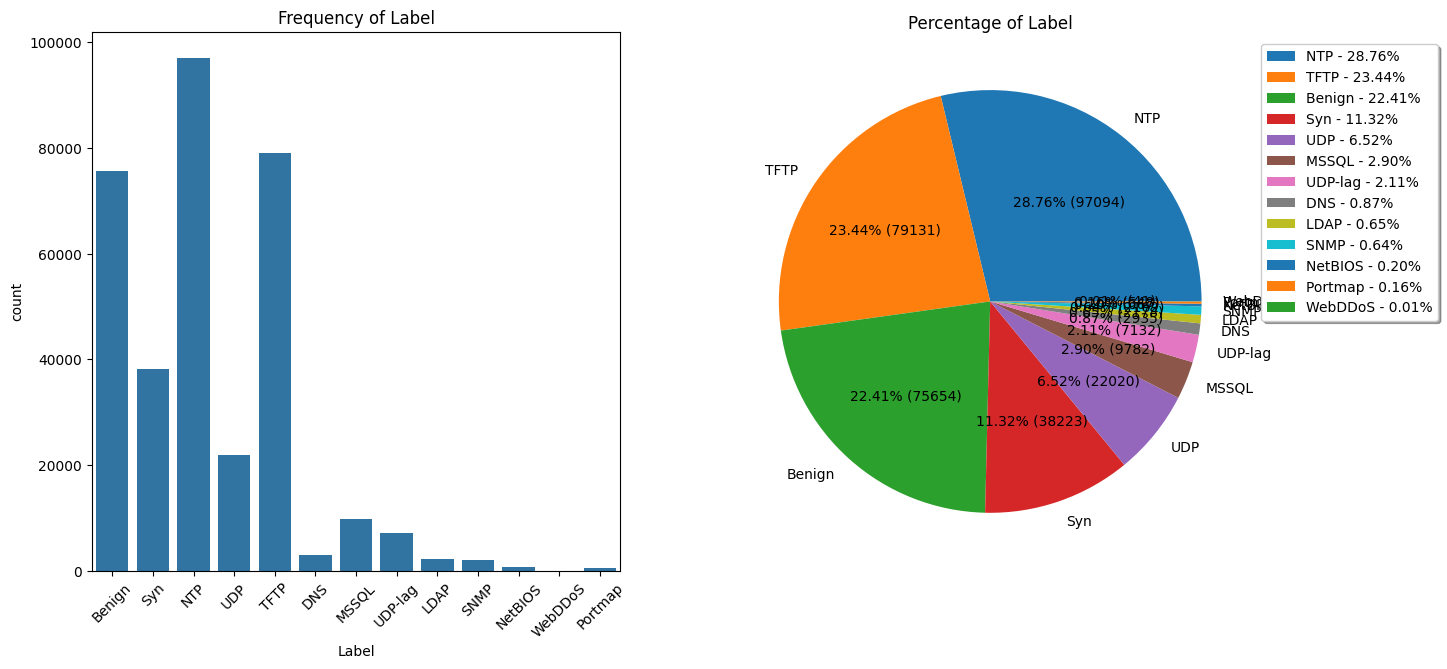

                ACK Flag Count      Ratio
ACK Flag Count                           
0                       278031  82.363205
1                        59536  17.636795




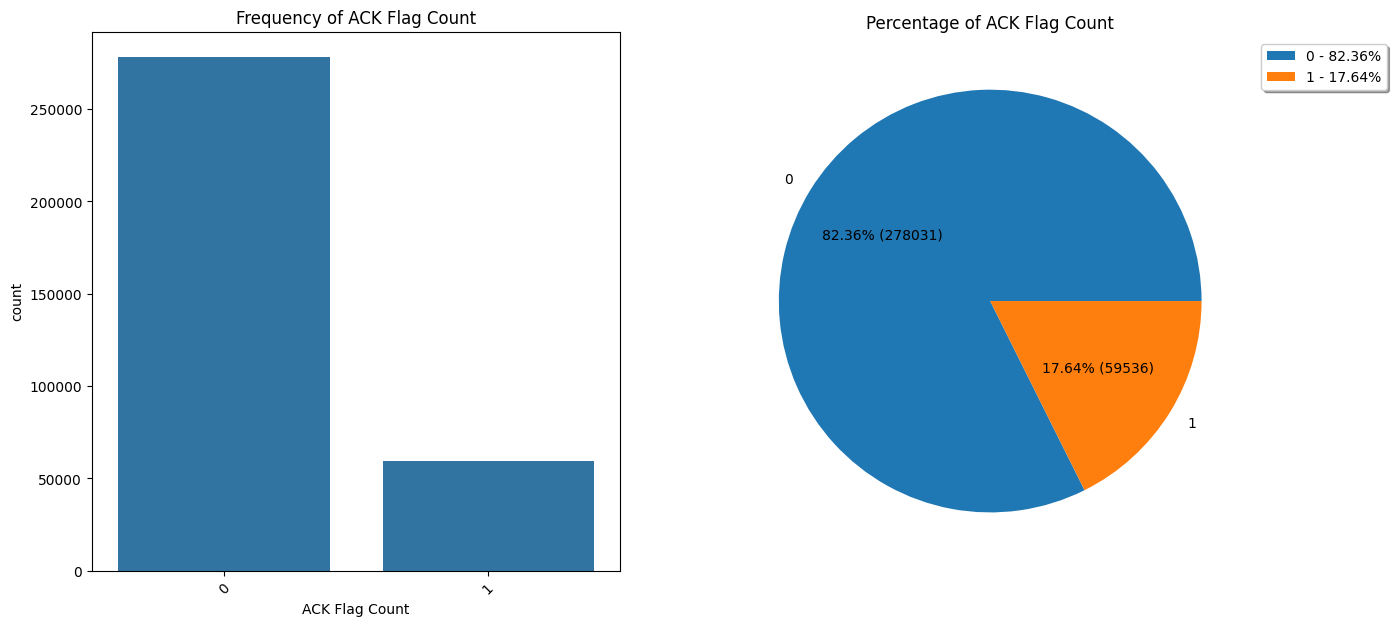

In [81]:
def cat_summary(data, col, plot=False):
    print(pd.DataFrame({col: data[col].value_counts(), "Ratio": data[col].value_counts() / len(data) * 100}))
    print("\n")

    if plot:
        fig, axs = plt.subplots(1, 2, figsize=(15, 7))
        plt.subplot(1, 2, 1)
        sns.countplot(x=col, data = data)
        plt.xticks(rotation=45)
        plt.title(f"Frequency of {col}")

        plt.subplot(1, 2, 2)
        values = data[col].value_counts()
        plt.pie(x=values, labels=values.index, autopct= lambda x: "{:.2f}% ({:.0f})".format(x, x/100 * sum(values)))
        plt.legend(labels = ['{} - {:.2f}%'.format(index, value / sum(values) * 100) for index, value in zip(values.index, values)],
                loc = "upper left",
                bbox_to_anchor = (1, 1),
                fancybox = True,
                shadow = True,
                ncol=1)
        plt.title(f"Percentage of {col}")
        plt.show(block=True)

cat_summary(pd.DataFrame(y_train, columns=['Label']), "Label", True)

for col in cat_columns:
    cat_summary(X_train, col, True)

### Numerical columns

In [82]:
# Distribution Plots for Numerical Columns

def my_histplot(data, col, ax):
    sns.histplot(x=col, data=data, kde=True, ax=ax)
    ax.set_title(f"Histogram of {col}")

def my_distplot(data, col, ax):
    sns.distplot(data[col], ax=ax)
    ax.set_title(f"Distribution of {col}")

def my_kdeplot(data, col, ax):
    sns.kdeplot(x=col, data=data, ax=ax)
    ax.set_title(f"KDE Plot of {col}")

# Relational Plots for Numerical Columns

def my_scatterplot(data, col, ax):
    sns.scatterplot(x=col, data=data, ax=ax)
    ax.set_title(f"Scatter Plot of {col}")

def my_lineplot(data, col, ax):
    sns.lineplot(x=col, data=data, ax=ax)
    ax.set_title(f"Line Plot of {col}")

# Categorical Plots for Categorical Columns

def my_pie_chart(data, col, ax):
    values = data[col].value_counts()
    ax.pie(x=values, labels=values.index, autopct= lambda x: "{:.2f}% ({:.0f})".format(x, x/100 * sum(values)))
    ax.legend(labels = ['{} - {:.2f}%'.format(index, value / sum(values) * 100) for index, value in zip(values.index, values)],
                loc = "upper left",
                bbox_to_anchor = (1, 1),
                fancybox = True,
                shadow = True,
                ncol=1)
    ax.set_title(f"Pie Chart of {col}")

def my_countplot(data, col, ax):
    sns.countplot(x=col, data=data, ax=ax)
    ax.set_title(f"Count Plot of {col}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

def my_boxplot(data, col, ax):
    sns.boxplot(y=col, data=data, ax=ax)

def my_violinplot(data, col, ax):
    sns.violinplot(y=col, data=data, ax=ax)

def my_swarmplot(data, col, ax):
    sns.swarmplot(y=col, data=data, ax=ax)

# Matrix Plots for Numerical Columns
def my_headmap(data, size):
    if size: plt.figure(figsize=size)
    sns.heatmap(data.corr(), annot=True, fmt=".1f", cmap="Blues", annot_kws={"size": 12})
    plt.title("Correlation Matrix")
    plt.show()

def my_vsplot(data, normal_col, label_col):
    plt.figure(figsize=(10, 6), dpi=80)
    plt.bar(list(dict(data[normal_col].value_counts()).key()), dict(data[normal_col].value_counts()).values(), color='r')
    plt.bar(list(dict(data[normal_col][data[label_col] == 1].value_counts()).keys()), dict(data[normal_col][data[label_col] == 1].value_counts()).values().keys(), dict(data[normal_col][data[label_col] == 1].value_counts()).values(), color='b')

    plt.xlabel(normal_col)
    plt.ylabel("Counts")
    plt.title(f"{normal_col} vs {label_col}")
    plt.show()

def plot_charts_grid_single_feature(data, plot_func, size=(12,4), n_col = 1):
    if len(data.columns) == 0:
        return
    n_rows = (len(data.columns) + n_col - 1)
    fig, axes = plt.subplots(n_rows, n_col, figsize=(size[0]*n_col, size[1]*n_rows))
    if len(data.columns) == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(data.columns):
        plot_func(data, col, axes[i])

    for j in range(i+1, n_rows*n_col):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()


In [83]:
# plot_charts_grid_single_feature(X_train[num_columns], my_histplot, size=(12, 4), n_col=2)

In [84]:
# plot_charts_grid_single_feature(X_train[num_columns], my_boxplot, size=(2, 4), n_col=6)

### Packet Size and Flow Duration Analysis

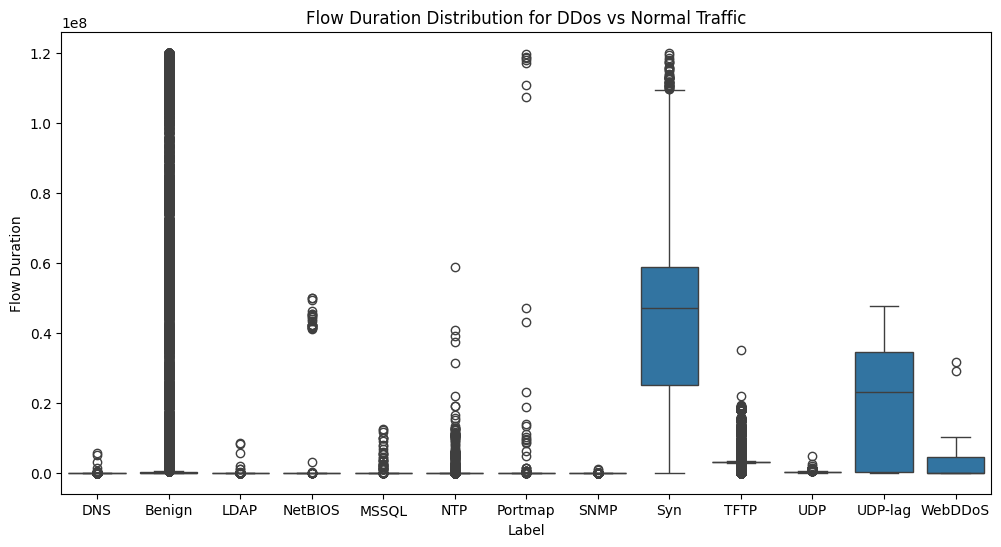

In [85]:
# Boxplot of Flow Duration by Attack Label
plt.figure(figsize=(12, 6))
sns.boxplot(x="Label", y="Flow Duration", data=df)
plt.title("Flow Duration Distribution for DDos vs Normal Traffic")
plt.show()

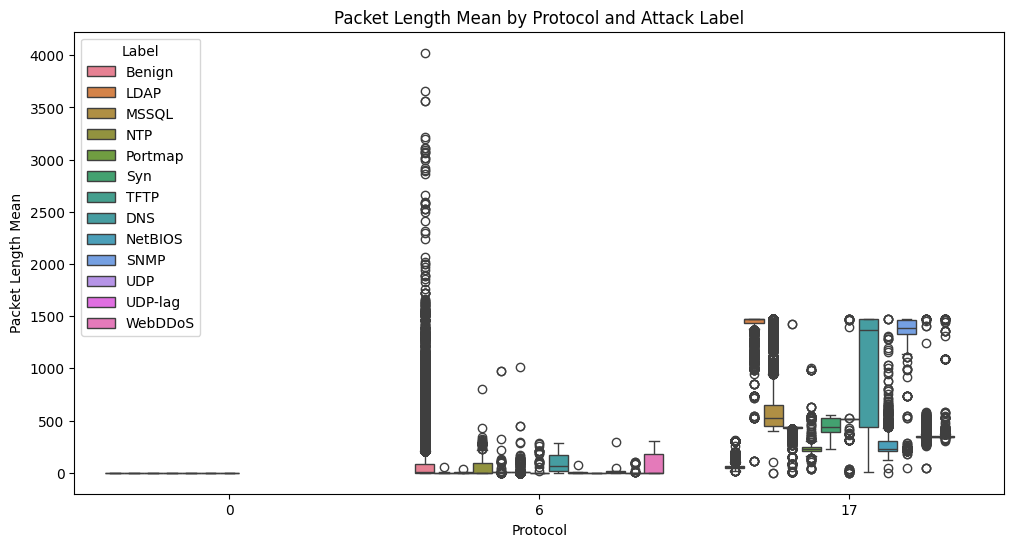

In [86]:
# Boxplot of Packet Length Mean by Protocol and Label
plt.figure(figsize=(12, 6))
sns.boxplot(x="Protocol", y="Packet Length Mean", hue="Label", data=df)
plt.title("Packet Length Mean by Protocol and Attack Label")
plt.show()

### Packet Flags and Attack Patterns

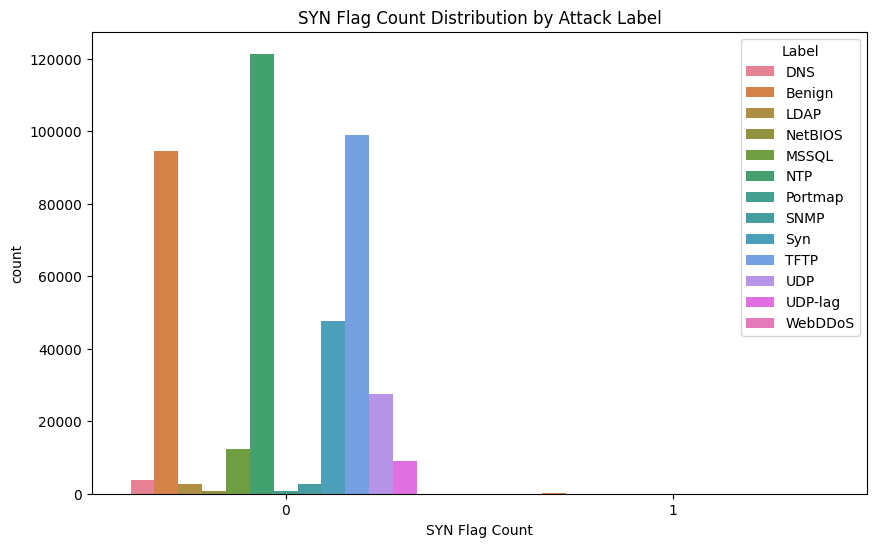

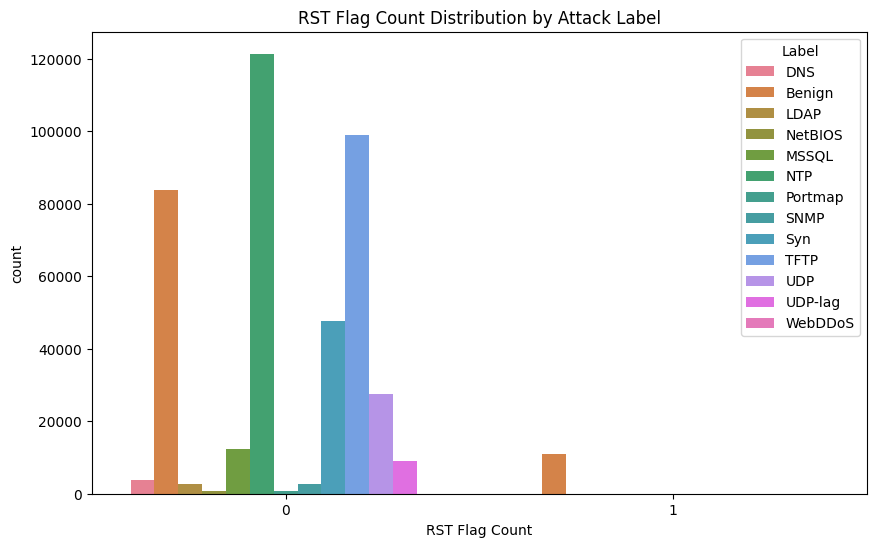

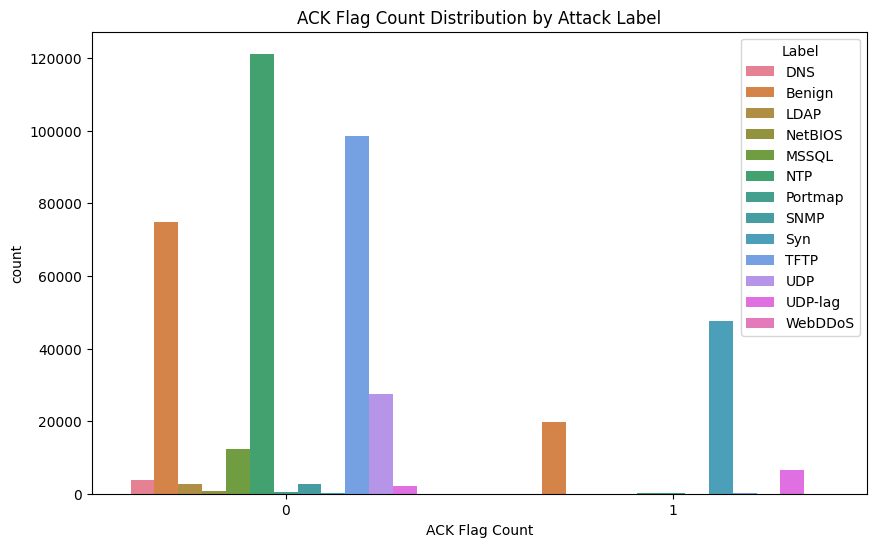

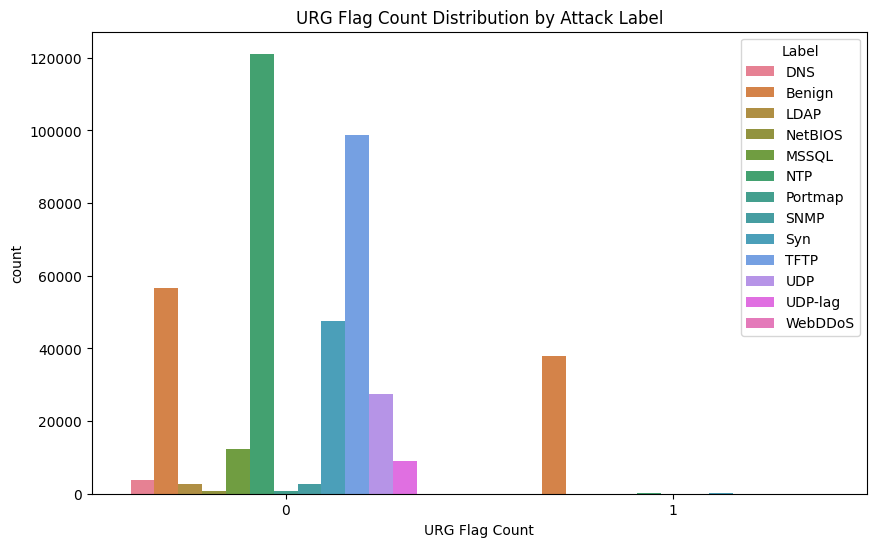

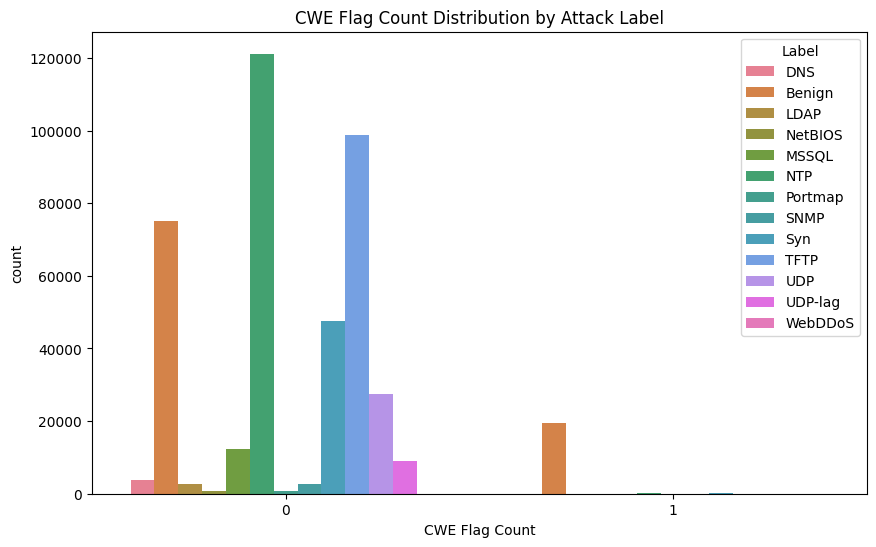

In [87]:
# Counting the number of occurrences of each flag in attack vs normal traffic

flag_cols = [col for col in df.columns if "Flag " in col]

for flag in flag_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=flag, hue="Label", data=df)
    plt.title(f"{flag} Distribution by Attack Label")
    plt.show()

## Encoding

### One Hot Encoding of categorical columns in X

In [88]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)

encoder.fit(X_train[cat_columns].astype(str))

X_train_cat_np = encoder.transform(X_train[cat_columns].astype(str))
X_test_cat_np = encoder.transform(X_test[cat_columns].astype(str))

X_train_cat = pd.DataFrame(X_train_cat_np, columns=encoder.get_feature_names_out(cat_columns), index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat_np, columns=encoder.get_feature_names_out(cat_columns), index=X_test.index)

In [89]:
X_train = pd.concat([X_train[X_train.columns.difference(X_train_cat.columns)], X_train_cat], axis=1)
X_test = pd.concat([X_test[X_test.columns.difference(X_test_cat.columns)], X_test_cat], axis=1)

# ── Report ────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print("POST-TRANSFORM STATE")
print("=" * 60)
print(f"  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"  X_test  : {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"  Dtypes  : {X_train.dtypes.value_counts().to_dict()}")
print(f"  NaN     : {X_train.isnull().sum().sum()}")
print(f"  Columns : {list(X_train.columns)}")


POST-TRANSFORM STATE
  X_train : 337,567 rows × 17 columns
  X_test  : 84,392 rows × 17 columns
  Dtypes  : {dtype('float32'): 11, dtype('int16'): 2, dtype('int64'): 2, dtype('int8'): 1, dtype('int32'): 1}
  NaN     : 0
  Columns : ['ACK Flag Count', 'Bwd Packets/s', 'Flow Bytes/s', 'Flow Duration', 'Flow IAT Max', 'Flow IAT Mean', 'Flow IAT Std', 'Flow Packets/s', 'Fwd Act Data Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packets Length Total', 'Fwd Packets/s', 'Packet Length Max', 'Total Backward Packets', 'ACK Flag Count_0', 'ACK Flag Count_1']


In [90]:
X_train.drop(columns=["ACK Flag Count"], inplace=True)

In [91]:
X_test.drop(columns=["ACK Flag Count"], inplace=True)

In [92]:
X_train

,Bwd Packets/s,Flow Bytes/s,Flow Duration,Flow IAT Max,Flow IAT Mean,Flow IAT Std,Flow Packets/s,Fwd Act Data Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packets Length Total,Fwd Packets/s,Packet Length Max,Total Backward Packets,ACK Flag Count_0,ACK Flag Count_1
267575,21.859596,1.442733e+03,91493,91004.0,1.829860e+04,4.064397e+04,4.198386,1,31.0,0.0,62.0,43.719193,35.0,2,1,0
219060,0.000000,9.402345e-01,38288320,21026384.0,7.657664e+06,1.056980e+07,0.145576,5,6.0,6.0,36.0,0.156706,6.0,0,0,1
117719,0.000000,1.190636e+07,1196,148.0,3.624242e+01,4.438118e+01,10.255168,33,440.0,80.0,14240.0,28428.093750,440.0,0,1,0
337093,0.287849,6.195516e+01,118117689,58504988.0,1.817195e+06,1.013371e+07,0.443894,20,1068.0,0.0,5286.0,0.270916,1068.0,34,0,1
60070,0.000000,4.723658e+07,1006,404.0,9.401869e+00,4.077824e+01,11.583914,107,440.0,440.0,47520.0,107355.867188,440.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
402107,0.058294,0.000000e+00,34308957,14032074.0,3.812106e+06,5.867956e+06,0.255780,0,0.0,0.0,0.0,0.233175,0.0,2,0,1
420007,0.729687,5.848731e+02,119229279,58962472.0,7.642902e+05,6.632628e+06,0.840183,68,1213.0,0.0,8780.0,0.587104,2526.0,87,0,1
183862,0.030779,1.108057e+00,64978627,20537644.0,5.907148e+06,8.413041e+06,0.169469,9,6.0,6.0,60.0,0.153897,6.0,2,0,1
396202,0.000000,8.016660e+03,549356,110705.0,4.994145e+04,5.737060e+04,3.128678,11,401.0,330.0,4404.0,21.843760,401.0,0,1,0


### Label Encoding target variable

In [93]:
import numpy as np

benign_label = 'Benign' 

y_train_encoded = (y_train != benign_label).astype(int)
y_test_encoded = (y_test != benign_label).astype(int)

print("Binary mapping complete!")
print(f"Train set - Benign (0): {sum(y_train_encoded == 0)}, Attacks (1): {sum(y_train_encoded == 1)}")
print(f"Test set  - Benign (0): {sum(y_test_encoded == 0)}, Attacks (1): {sum(y_test_encoded == 1)}")

Binary mapping complete!
Train set - Benign (0): 75654, Attacks (1): 261913
Test set  - Benign (0): 18914, Attacks (1): 65478


## Model Training

In [94]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=150, 
    max_depth=6, 
    learning_rate=0.1, 
    tree_method='hist', 
    n_jobs=-1, 
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test_encoded, y_pred_xgb) * 100:.4f}%\n")

XGBoost Accuracy: 99.8460%



In [95]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

def generate_model_report(model_name, model, X_test, y_test):
    print(f"==========================================")
    print(f"  PERFORMANCE REPORT: {model_name}")
    print(f"==========================================")
    
    # Get predictions
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy Score: {acc * 100:.2f}%\n")
    
    print("--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Attack (1)']))
    
    print("--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm, 
        index=['Actual Benign (0)', 'Actual Attack (1)'], 
        columns=['Predicted Benign (0)', 'Predicted Attack (1)']
    )
    print(cm_df)
    print(f"==========================================\n")

generate_model_report("XGBoost", xgb_model, X_test, y_test_encoded)

  PERFORMANCE REPORT: XGBoost
Accuracy Score: 99.85%

--- Classification Report ---
              precision    recall  f1-score   support

  Benign (0)       1.00      1.00      1.00     18914
  Attack (1)       1.00      1.00      1.00     65478

    accuracy                           1.00     84392
   macro avg       1.00      1.00      1.00     84392
weighted avg       1.00      1.00      1.00     84392

--- Confusion Matrix ---
                   Predicted Benign (0)  Predicted Attack (1)
Actual Benign (0)                 18876                    38
Actual Attack (1)                    92                 65386



In [96]:

import joblib
import json
import os

# ── 1. Create the output folder ───────────────────────────
output_folder = "../ml/model"
os.makedirs(output_folder, exist_ok=True)
print(f"✅ Folder ready: {output_folder}")

# ── 2. Save the XGBoost model ─────────────────────────────
model_path = os.path.join(output_folder, "nids_model.pkl")
joblib.dump(xgb_model, model_path)

model_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"✅ Model saved:   {model_path}  ({model_size:.2f} MB)")

# ── 3. Save the One-Hot Encoder ───────────────────────────
encoder_path = os.path.join(output_folder, "nids_encoder.pkl")
joblib.dump(encoder, encoder_path)

encoder_size = os.path.getsize(encoder_path) / (1024 * 1024)
print(f"✅ Encoder saved: {encoder_path}  ({encoder_size:.4f} MB)")

# ── 4. Build and save the metadata JSON ───────────────────
# This file is the instruction manual for the Phase 2 sensor.
# It tells the sensor exactly what to calculate and in what order.

metadata = {

    "model_info": {
        "type": "XGBClassifier",
        "accuracy_percent": 99.85,
        "labels": {
            "0": "BENIGN",
            "1": "MALICIOUS"
        },
        "total_input_columns": 16,
        "classification_threshold": 0.5
    },

    # These 14 columns are fed into the model AS-IS (no encoding needed)
    # The sensor must calculate these 14 values from live packets
    "numeric_features": [
        "Bwd Packets/s",
        "Flow Bytes/s",
        "Flow Duration",
        "Flow IAT Max",
        "Flow IAT Mean",
        "Flow IAT Std",
        "Flow Packets/s",
        "Fwd Act Data Packets",
        "Fwd Packet Length Max",
        "Fwd Packet Length Min",
        "Fwd Packets Length Total",
        "Fwd Packets/s",
        "Packet Length Max",
        "Total Backward Packets"
    ],

    # This 1 column needs to be One-Hot Encoded before feeding to the model
    # The encoder will turn it into 2 columns: ACK Flag Count_0, ACK Flag Count_1
    "categorical_features": {
        "ACK Flag Count": {
            "encoding": "OneHotEncoder",
            "categories": ["0", "1"],
            "output_columns": ["ACK Flag Count_0", "ACK Flag Count_1"],
            "position_in_model_input": [14, 15]
        }
    },

    # The exact final column order the model was trained on
    # The sensor must produce columns in THIS exact order
    "final_column_order": [
        "Bwd Packets/s",
        "Flow Bytes/s",
        "Flow Duration",
        "Flow IAT Max",
        "Flow IAT Mean",
        "Flow IAT Std",
        "Flow Packets/s",
        "Fwd Act Data Packets",
        "Fwd Packet Length Max",
        "Fwd Packet Length Min",
        "Fwd Packets Length Total",
        "Fwd Packets/s",
        "Packet Length Max",
        "Total Backward Packets",
        "ACK Flag Count_0",
        "ACK Flag Count_1"
    ],

    # Data types the sensor should cast each numeric feature to
    # This matches your training dtypes exactly
    "feature_dtypes": {
        "Bwd Packets/s": "float32",
        "Flow Bytes/s": "float32",
        "Flow Duration": "int32",
        "Flow IAT Max": "float32",
        "Flow IAT Mean": "float32",
        "Flow IAT Std": "float32",
        "Flow Packets/s": "float32",
        "Fwd Act Data Packets": "int16",
        "Fwd Packet Length Max": "float32",
        "Fwd Packet Length Min": "float32",
        "Fwd Packets Length Total": "float32",
        "Fwd Packets/s": "float32",
        "Packet Length Max": "float32",
        "Total Backward Packets": "int16",
        "ACK Flag Count_0": "int64",
        "ACK Flag Count_1": "int64"
    }
}

metadata_path = os.path.join(output_folder, "nids_metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✅ Metadata saved: {metadata_path}")


for filename in os.listdir(output_folder):
    filepath = os.path.join(output_folder, filename)
    size = os.path.getsize(filepath) / (1024 * 1024)
    print(f"  📄 {filename:<30} {size:.4f} MB")

print(f"  • nids_model.pkl     → The trained brain")
print(f"  • nids_encoder.pkl   → The preprocessing rule")
print(f"  • nids_metadata.json → The instruction manual")

✅ Folder ready: ../ml/model
✅ Model saved:   ../ml/model\nids_model.pkl  (0.38 MB)
✅ Encoder saved: ../ml/model\nids_encoder.pkl  (0.0009 MB)
✅ Metadata saved: ../ml/model\nids_metadata.json
  📄 nids_encoder.pkl               0.0009 MB
  📄 nids_metadata.json             0.0019 MB
  📄 nids_model.pkl                 0.3788 MB
  • nids_model.pkl     → The trained brain
  • nids_encoder.pkl   → The preprocessing rule
  • nids_metadata.json → The instruction manual


In [97]:
# Fine-tuning test — pushing above 80%

# Test 4 — Push packets/s higher
test_prediction({
    "Bwd Packets/s":            np.float32(10000),
    "Flow Bytes/s":             np.float32(50000),
    "Flow Duration":            np.int32(1000000),
    "Flow IAT Max":             np.float32(100),
    "Flow IAT Mean":            np.float32(10),
    "Flow IAT Std":             np.float32(5),
    "Flow Packets/s":           np.float32(20000),
    "Fwd Act Data Packets":     np.int16(0),
    "Fwd Packet Length Max":    np.float32(0),
    "Fwd Packet Length Min":    np.float32(0),
    "Fwd Packets Length Total": np.float32(0),
    "Fwd Packets/s":            np.float32(10000),
    "Packet Length Max":        np.float32(0),
    "Total Backward Packets":   np.int16(10000),
    "ACK Flag Count":           '0'
}, "Test 4 — Higher packets/s")

# Test 5 — Near zero everything except packet rate
test_prediction({
    "Bwd Packets/s":            np.float32(20000),
    "Flow Bytes/s":             np.float32(0),
    "Flow Duration":            np.int32(500000),
    "Flow IAT Max":             np.float32(50),
    "Flow IAT Mean":            np.float32(5),
    "Flow IAT Std":             np.float32(1),
    "Flow Packets/s":           np.float32(40000),
    "Fwd Act Data Packets":     np.int16(0),
    "Fwd Packet Length Max":    np.float32(0),
    "Fwd Packet Length Min":    np.float32(0),
    "Fwd Packets Length Total": np.float32(0),
    "Fwd Packets/s":            np.float32(20000),
    "Packet Length Max":        np.float32(0),
    "Total Backward Packets":   np.int16(20000),
    "ACK Flag Count":           '0'
}, "Test 5 — Very high rate")

# Test 6 — Exactly like Test 1 but lower threshold check
test_prediction({
    "Bwd Packets/s":            np.float32(15000),
    "Flow Bytes/s":             np.float32(10000),
    "Flow Duration":            np.int32(1000000),
    "Flow IAT Max":             np.float32(200),
    "Flow IAT Mean":            np.float32(20),
    "Flow IAT Std":             np.float32(5),
    "Flow Packets/s":           np.float32(30000),
    "Fwd Act Data Packets":     np.int16(0),
    "Fwd Packet Length Max":    np.float32(0),
    "Fwd Packet Length Min":    np.float32(0),
    "Fwd Packets Length Total": np.float32(0),
    "Fwd Packets/s":            np.float32(15000),
    "Packet Length Max":        np.float32(0),
    "Total Backward Packets":   np.int16(15000),
    "ACK Flag Count":           '0'
}, "Test 6 — Balanced high rate")

# Test 7 — Lower the threshold instead to 70%
# Just checking what value triggers consistently
test_prediction({
    "Bwd Packets/s":            np.float32(8000),
    "Flow Bytes/s":             np.float32(30000),
    "Flow Duration":            np.int32(1000000),
    "Flow IAT Max":             np.float32(300),
    "Flow IAT Mean":            np.float32(30),
    "Flow IAT Std":             np.float32(10),
    "Flow Packets/s":           np.float32(16000),
    "Fwd Act Data Packets":     np.int16(0),
    "Fwd Packet Length Max":    np.float32(0),
    "Fwd Packet Length Min":    np.float32(0),
    "Fwd Packets Length Total": np.float32(0),
    "Fwd Packets/s":            np.float32(8000),
    "Packet Length Max":        np.float32(0),
    "Total Backward Packets":   np.int16(8000),
    "ACK Flag Count":           '0'
}, "Test 7 — Moderate high rate")

NameError: name 'test_prediction' is not defined